# 🩺 Preprocessing: Diabetes Health Indicators Dataset (BRFSS 2015)

**Dataset:** `diabetes_012_health_indicators_BRFSS2015.csv`  
**Source:** [Kaggle - Alex Teboul](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)

---

### 📋 Alur Preprocessing:

1. Load & Inspeksi Awal
2. Pemahaman Fitur (Data Dictionary)
3. Pengecekan Missing Values
4. Pengecekan Duplikat
5. Analisis Distribusi & Outlier
6. Penanganan Outlier
7. Encoding Fitur Kategorikal
8. Feature Scaling / Normalisasi
9. Penanganan Class Imbalance
10. Feature Selection
11. Split Data (Train/Val/Test)
12. Simpan Data Hasil Preprocessing


## 0️⃣ Install & Import Library


In [ ]:
# Install library tambahan jika belum ada
pip install imbalanced-learn -q

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 📂 Upload / Mount Dataset

> **Pilih salah satu cara** load data di bawah ini (uncomment yang sesuai).


In [29]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

ModuleNotFoundError: No module named 'google'

In [30]:
df = pd.read_csv("/media/fatih/Data/KULIAH/KULIAH/sains-data/smt4/kda/PROJEK/kda-projek-kelompok-2/data/raw/diabetes__health_indicators.csv")

---

## 1️⃣ Inspeksi Awal Dataset


In [31]:
print('=' * 60)
print(f'SHAPE     : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print('=' * 60)
df.head()

SHAPE     : 253,680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0000,1.0000,1.0000,1.0000,40.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,5.0000,18.0000,15.0000,1.0000,0.0000,9.0000,4.0000,3.0000
1,0.0000,0.0000,0.0000,0.0000,25.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,0.0000,0.0000,0.0000,0.0000,7.0000,6.0000,1.0000
2,0.0000,1.0000,1.0000,1.0000,28.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,5.0000,30.0000,30.0000,1.0000,0.0000,9.0000,4.0000,8.0000
3,0.0000,1.0000,0.0000,1.0000,27.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,11.0000,3.0000,6.0000
4,0.0000,1.0000,1.0000,1.0000,24.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,3.0000,0.0000,0.0000,0.0000,11.0000,5.0000,4.0000


In [32]:
print('Tipe Data & Non-Null Count:')
df.info()

Tipe Data & Non-Null Count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               25

In [33]:
print('Statistik Deskriptif:')
df.describe().T

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0000,0.2969,0.6982,0.0000,0.0000,0.0000,0.0000,2.0000
HighBP,253680.0000,0.4290,0.4949,0.0000,0.0000,0.0000,1.0000,1.0000
HighChol,253680.0000,0.4241,0.4942,0.0000,0.0000,0.0000,1.0000,1.0000
CholCheck,253680.0000,0.9627,0.1896,0.0000,1.0000,1.0000,1.0000,1.0000
BMI,253680.0000,28.3824,6.6087,12.0000,24.0000,27.0000,31.0000,98.0000
Smoker,253680.0000,0.4432,0.4968,0.0000,0.0000,0.0000,1.0000,1.0000
Stroke,253680.0000,0.0406,0.1973,0.0000,0.0000,0.0000,0.0000,1.0000
HeartDiseaseorAttack,253680.0000,0.0942,0.2921,0.0000,0.0000,0.0000,0.0000,1.0000
PhysActivity,253680.0000,0.7565,0.4292,0.0000,1.0000,1.0000,1.0000,1.0000
Fruits,253680.0000,0.6343,0.4816,0.0000,0.0000,1.0000,1.0000,1.0000


---

## 2️⃣ Data Dictionary & Tipe Fitur

Klasifikasi fitur berdasarkan jenisnya:


In [34]:
data_dict = {
    'Kolom': [
        'Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
        'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
        'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
        'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth',
        'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
    ],
    'Deskripsi': [
        'Target: 0=No diabetes, 1=Prediabetes, 2=Diabetes',
        'Tekanan darah tinggi (0=Tidak, 1=Ya)',
        'Kolesterol tinggi (0=Tidak, 1=Ya)',
        'Cek kolesterol ≥5 tahun terakhir (0=Tidak, 1=Ya)',
        'Body Mass Index (numerik kontinu)',
        'Pernah merokok ≥100 batang seumur hidup (0=Tidak, 1=Ya)',
        'Pernah stroke (0=Tidak, 1=Ya)',
        'Penyakit jantung atau serangan jantung (0=Tidak, 1=Ya)',
        'Aktivitas fisik dalam 30 hari terakhir (0=Tidak, 1=Ya)',
        'Konsumsi buah ≥1x sehari (0=Tidak, 1=Ya)',
        'Konsumsi sayur ≥1x sehari (0=Tidak, 1=Ya)',
        'Konsumsi alkohol berat (0=Tidak, 1=Ya)',
        'Memiliki asuransi kesehatan (0=Tidak, 1=Ya)',
        'Tidak periksa dokter karena biaya (0=Tidak, 1=Ya)',
        'Kesehatan umum: 1=Sangat Baik s.d. 5=Buruk (ordinal)',
        'Hari kesehatan mental buruk (0-30 hari)',
        'Hari kesehatan fisik buruk (0-30 hari)',
        'Kesulitan berjalan/naik tangga (0=Tidak, 1=Ya)',
        'Jenis kelamin (0=Perempuan, 1=Laki-laki)',
        'Kelompok usia (1=18-24 s.d. 13=80+) ordinal',
        'Tingkat pendidikan (1-6) ordinal',
        'Tingkat pendapatan (1-8) ordinal'
    ],
    'Tipe': [
        'Target (Multiclass)', 'Biner', 'Biner', 'Biner', 'Kontinu',
        'Biner', 'Biner', 'Biner', 'Biner',
        'Biner', 'Biner', 'Biner', 'Biner',
        'Biner', 'Ordinal', 'Kontinu', 'Kontinu',
        'Biner', 'Biner', 'Ordinal', 'Ordinal', 'Ordinal'
    ]
}

dict_df = pd.DataFrame(data_dict)
print('Data Dictionary:')
dict_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white')]}]
)

Data Dictionary:


,Kolom,Deskripsi,Tipe
0,Diabetes_012,"Target: 0=No diabetes, 1=Prediabetes, 2=Diabetes",Target (Multiclass)
1,HighBP,"Tekanan darah tinggi (0=Tidak, 1=Ya)",Biner
2,HighChol,"Kolesterol tinggi (0=Tidak, 1=Ya)",Biner
3,CholCheck,"Cek kolesterol ≥5 tahun terakhir (0=Tidak, 1=Ya)",Biner
4,BMI,Body Mass Index (numerik kontinu),Kontinu
5,Smoker,"Pernah merokok ≥100 batang seumur hidup (0=Tidak, 1=Ya)",Biner
6,Stroke,"Pernah stroke (0=Tidak, 1=Ya)",Biner
7,HeartDiseaseorAttack,"Penyakit jantung atau serangan jantung (0=Tidak, 1=Ya)",Biner
8,PhysActivity,"Aktivitas fisik dalam 30 hari terakhir (0=Tidak, 1=Ya)",Biner
9,Fruits,"Konsumsi buah ≥1x sehari (0=Tidak, 1=Ya)",Biner


In [35]:
TARGET = 'Diabetes_012'

BINARY_FEATURES = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

ORDINAL_FEATURES = ['GenHlth', 'Age', 'Education', 'Income']

CONTINUOUS_FEATURES = ['BMI', 'MentHlth', 'PhysHlth']

print(f'Target       : {TARGET}')
print(f'Biner        : {len(BINARY_FEATURES)} fitur → {BINARY_FEATURES}')
print(f'Ordinal      : {len(ORDINAL_FEATURES)} fitur → {ORDINAL_FEATURES}')
print(f'Kontinu      : {len(CONTINUOUS_FEATURES)} fitur → {CONTINUOUS_FEATURES}')

Target       : Diabetes_012
Biner        : 14 fitur → ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal      : 4 fitur → ['GenHlth', 'Age', 'Education', 'Income']
Kontinu      : 3 fitur → ['BMI', 'MentHlth', 'PhysHlth']


---

## 3️⃣ Pengecekan Missing Values


In [36]:
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

if missing['Jumlah Missing'].sum() == 0:
    print('Tidak ada missing values dalam dataset ini!')
else:
    print('Kolom dengan missing values:')
    print(missing[missing['Jumlah Missing'] > 0])

    plt.figure(figsize=(10, 4))
    missing[missing['Jumlah Missing'] > 0]['Persentase (%)'].plot(kind='bar', color='tomato')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Persentase (%)')
    plt.tight_layout()
    plt.show()

missing

Tidak ada missing values dalam dataset ini!


,Jumlah Missing,Persentase (%)
Diabetes_012,0,0.0000
HighBP,0,0.0000
HighChol,0,0.0000
CholCheck,0,0.0000
BMI,0,0.0000
Smoker,0,0.0000
Stroke,0,0.0000
HeartDiseaseorAttack,0,0.0000
PhysActivity,0,0.0000
Fruits,0,0.0000


---

## 4️⃣ Pengecekan & Penghapusan Duplikat


In [37]:
n_duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_duplikat:,}')
print(f'   Persentase           : {n_duplikat/len(df)*100:.2f}%')

if n_duplikat > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplikat dihapus. Shape baru: {df.shape}')
else:
    print('Tidak ada duplikat ditemukan.')

Jumlah baris duplikat: 23,899
   Persentase           : 9.42%
Duplikat dihapus. Shape baru: (229781, 22)


---

## 5️⃣ Analisis Distribusi & Target


Distribusi Kelas Target (Diabetes_012):
                    Label  Jumlah  Persentase %
Diabetes_012                                   
0.0000        No Diabetes  190055       82.7100
1.0000        Prediabetes    4629        2.0100
2.0000           Diabetes   35097       15.2700


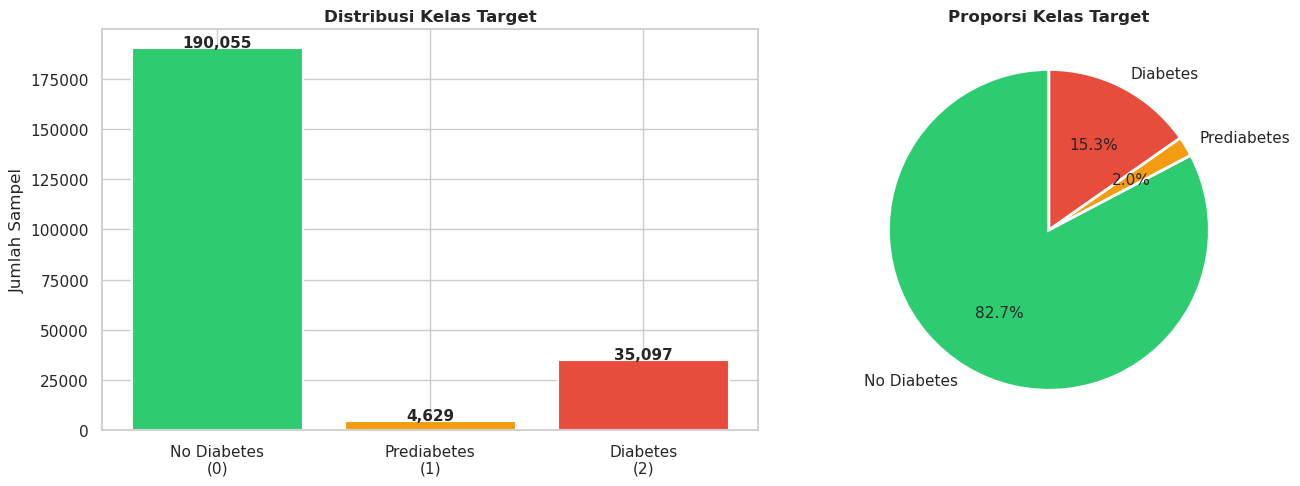

In [38]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct    = df[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Label'       : ['No Diabetes', 'Prediabetes', 'Diabetes'],
    'Jumlah'      : target_counts.values,
    'Persentase %': target_pct.values.round(2)
}, index=target_counts.index)

print('Distribusi Kelas Target (Diabetes_012):')
print(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(['No Diabetes\n(0)', 'Prediabetes\n(1)', 'Diabetes\n(2)'],
            target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Kelas Target', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.tight_layout()
plt.show()

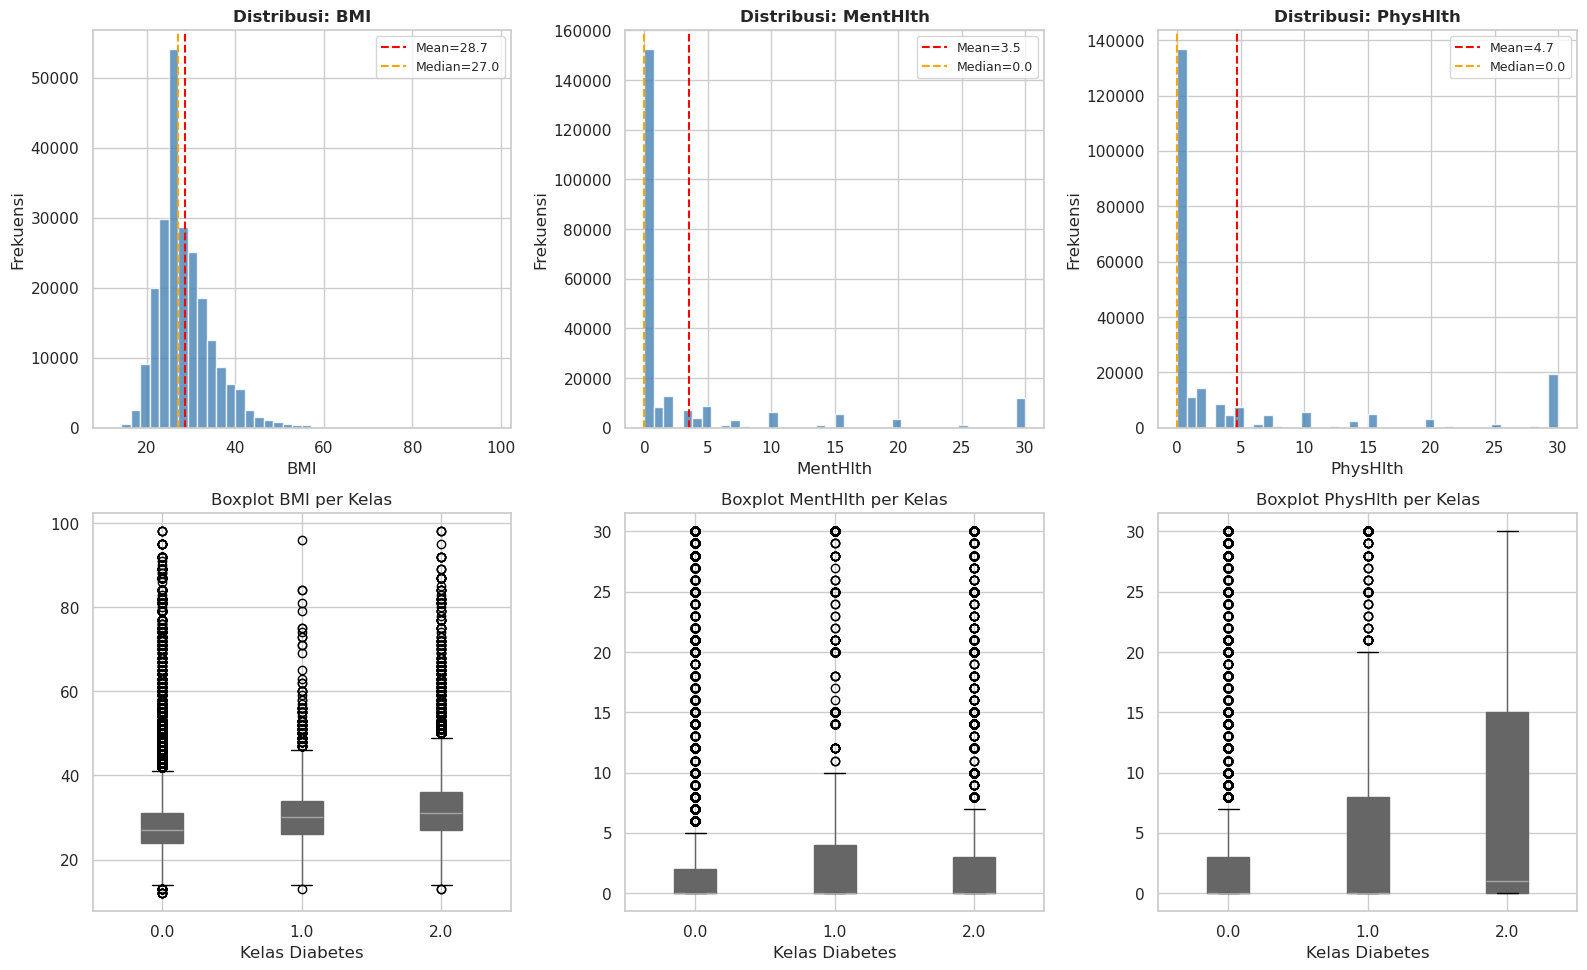

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_FEATURES):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median={df[col].median():.1f}')
    axes[i].legend(fontsize=9)

for j, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[3 + j]
    df.boxplot(column=col, by=TARGET, ax=ax, patch_artist=True)
    ax.set_title(f'Boxplot {col} per Kelas', fontweight='bold')
    ax.set_xlabel('Kelas Diabetes')
    plt.sca(ax)
    plt.title(f'Boxplot {col} per Kelas')

plt.suptitle('')
plt.tight_layout()
plt.show()

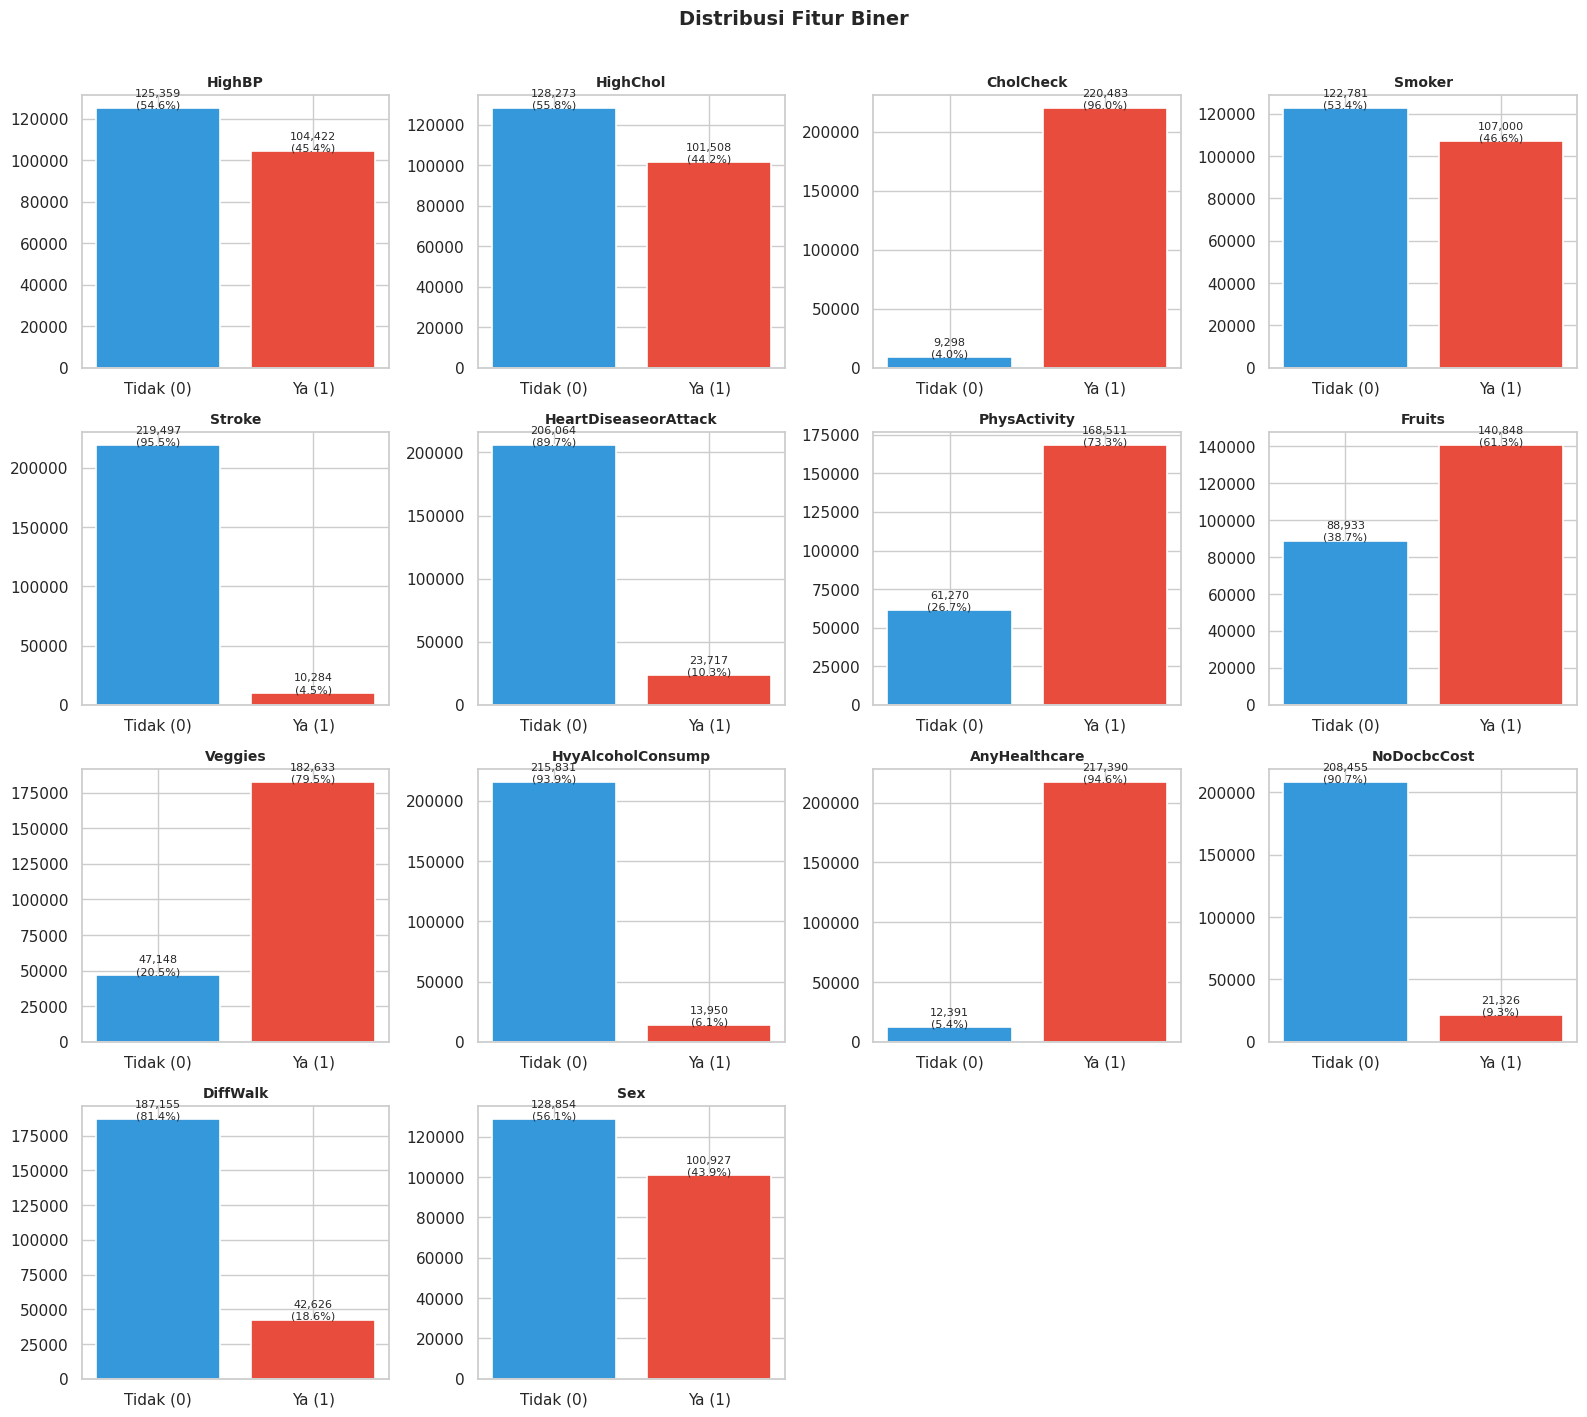

In [40]:
n_cols = 4
n_rows = (len(BINARY_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(BINARY_FEATURES):
    val_counts = df[col].value_counts().sort_index()
    axes[i].bar(['Tidak (0)', 'Ya (1)'], val_counts.values,
                color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    for k, v in enumerate(val_counts.values):
        axes[i].text(k, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Biner', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 6️⃣ Deteksi & Penanganan Outlier (Fitur Kontinu)


In [41]:
def detect_outliers_iqr(df, columns):
    """Deteksi outlier menggunakan metode IQR"""
    results = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            'Fitur'       : col,
            'Q1'          : round(Q1, 2),
            'Q3'          : round(Q3, 2),
            'IQR'         : round(IQR, 2),
            'Batas Bawah' : round(lower, 2),
            'Batas Atas'  : round(upper, 2),
            'Jml Outlier' : n_out,
            'Pct Outlier%': round(n_out / len(df) * 100, 2)
        })
    return pd.DataFrame(results)

outlier_report = detect_outliers_iqr(df, CONTINUOUS_FEATURES)
print('Laporan Outlier (Metode IQR):')
outlier_report

Laporan Outlier (Metode IQR):


,Fitur,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jml Outlier,Pct Outlier%
0,BMI,24.0000,32.0000,8.0000,12.0000,44.0000,5638,2.4500
1,MentHlth,0.0000,2.0000,2.0000,-3.0000,5.0000,36163,15.7400
2,PhysHlth,0.0000,4.0000,4.0000,-6.0000,10.0000,34347,14.9500


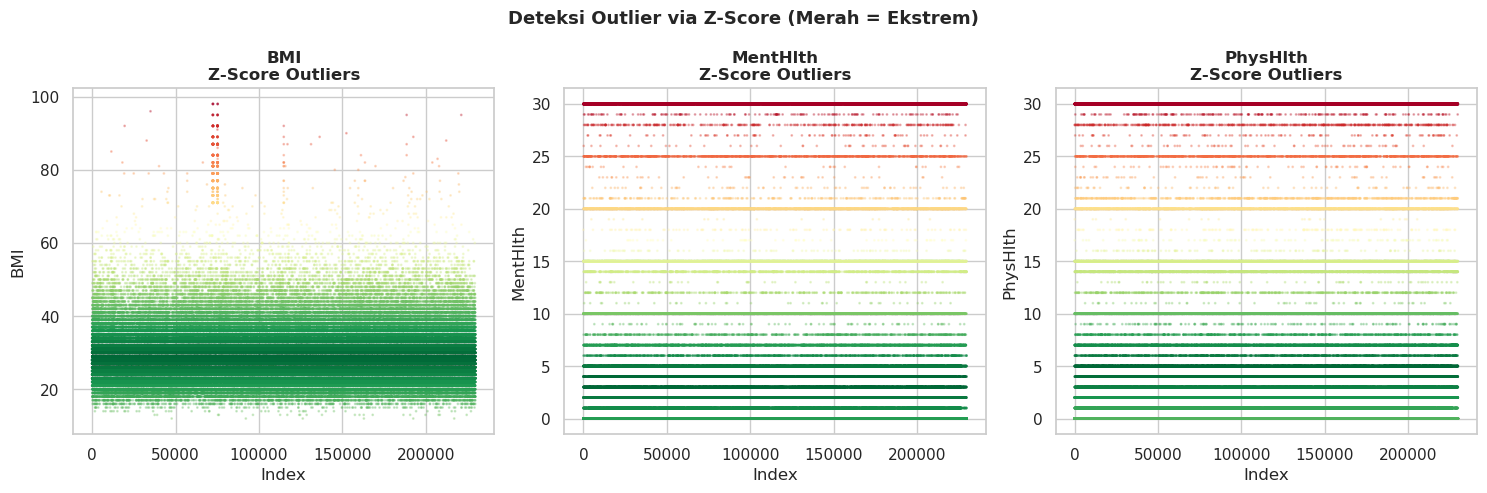

In [42]:
fig, axes = plt.subplots(1, len(CONTINUOUS_FEATURES), figsize=(15, 5))

for i, col in enumerate(CONTINUOUS_FEATURES):
    z_scores = np.abs(stats.zscore(df[col]))
    axes[i].scatter(range(len(df)), df[col], c=z_scores, cmap='RdYlGn_r',
                    alpha=0.3, s=1)
    axes[i].set_title(f'{col}\nZ-Score Outliers', fontweight='bold')
    axes[i].set_xlabel('Index')
    axes[i].set_ylabel(col)

plt.suptitle('Deteksi Outlier via Z-Score (Merah = Ekstrem)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
OUTLIER_FEATURES = ['BMI']

df_clean = df.copy()

for col in OUTLIER_FEATURES:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # clipping / winsorizing
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f' {col}: clipping ke [{lower:.2f}, {upper:.2f}]')

print(f'\nShape setelah capping: {df_clean.shape}')

 BMI: clipping ke [12.00, 44.00]

Shape setelah capping: (229781, 22)


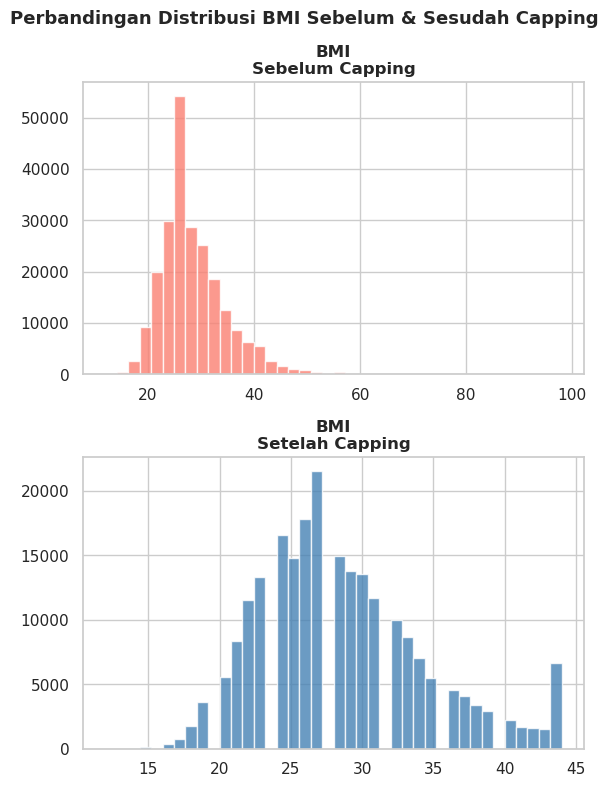

In [44]:
fig, axes = plt.subplots(2, len(OUTLIER_FEATURES), figsize=(6, 8))

if len(OUTLIER_FEATURES) == 1:
    axes = np.array(axes).reshape(2,1)

for i, col in enumerate(OUTLIER_FEATURES):

    axes[0, i].hist(
        df[col],
        bins=40,
        color='salmon',
        edgecolor='white',
        alpha=0.8
    )
    axes[0, i].set_title(
        f'{col}\nSebelum Capping',
        fontweight='bold'
    )

    axes[1, i].hist(
        df_clean[col],
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.8
    )
    axes[1, i].set_title(
        f'{col}\nSetelah Capping',
        fontweight='bold'
    )

plt.suptitle(
    'Perbandingan Distribusi BMI Sebelum & Sesudah Capping',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---

## 7️⃣ Encoding Fitur Kategorikal

Dataset ini sudah dalam bentuk numerik, namun kita perlu memastikan tipe data sudah benar.


In [45]:
for col in BINARY_FEATURES:
    df_clean[col] = df_clean[col].astype('int8')

for col in ORDINAL_FEATURES:
    df_clean[col] = df_clean[col].astype('int8')

df_clean[TARGET] = df_clean[TARGET].astype('int8')

print(' Tipe data setelah konversi:')
print(df_clean.dtypes)
print(f'\n Penggunaan memori: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

 Tipe data setelah konversi:
Diabetes_012               int8
HighBP                     int8
HighChol                   int8
CholCheck                  int8
BMI                     float64
Smoker                     int8
Stroke                     int8
HeartDiseaseorAttack       int8
PhysActivity               int8
Fruits                     int8
Veggies                    int8
HvyAlcoholConsump          int8
AnyHealthcare              int8
NoDocbcCost                int8
GenHlth                    int8
MentHlth                float64
PhysHlth                float64
DiffWalk                   int8
Sex                        int8
Age                        int8
Education                  int8
Income                     int8
dtype: object

 Penggunaan memori: 9.42 MB


In [46]:
df_privacy = df_clean.copy()

df_ml = df_clean.copy()

print('Dataset dipisah:')
print(f'   df_privacy : {df_privacy.shape}')
print(f'   df_ml      : {df_ml.shape}')

Dataset dipisah:
   df_privacy : (229781, 22)
   df_ml      : (229781, 22)


---

## 9️⃣ Attribute Role Definition


In [47]:
IDENTIFIER_ATTRIBUTES = []

QI_ATTRIBUTES = [
    'Age',
    'Sex',
    'Education',
    'Income',
    'BMI',
    'GenHlth'
]

SENSITIVE_ATTRIBUTE = 'Diabetes_012'

SENSITIVE_CANDIDATES = [
    'Diabetes_012',
    'HighBP',
    'HighChol',
    'HeartDiseaseorAttack',
    'Stroke'
]

NON_SENSITIVE_ATTRIBUTES = [
    'Smoker',
    'HvyAlcoholConsump',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'CholCheck',
    'AnyHealthcare',
    'NoDocbcCost'
]

print('Identifier Attributes:', IDENTIFIER_ATTRIBUTES)
print('Quasi-Identifier Attributes:', QI_ATTRIBUTES)
print('Sensitive Attribute:', SENSITIVE_ATTRIBUTE)
print('Non-Sensitive Attributes:', NON_SENSITIVE_ATTRIBUTES)

Identifier Attributes: []
Quasi-Identifier Attributes: ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']
Sensitive Attribute: Diabetes_012
Non-Sensitive Attributes: ['Smoker', 'HvyAlcoholConsump', 'PhysActivity', 'Fruits', 'Veggies', 'MentHlth', 'PhysHlth', 'DiffWalk', 'CholCheck', 'AnyHealthcare', 'NoDocbcCost']


---

## 🔟 Generalization


In [48]:
# ================================
# CONFIGURATION & CONSTANTS
# ================================

# Privacy parameters
K_ANONYMITY = 5          # Minimum group size
EPSILON = 1.0            # Privacy budget
MAX_LEVEL = 3            # Maximum generalization level (0-3)

# QI Attributes (already defined, but reconfirm)
QI_ATTRIBUTES = [
    'Age',
    'Sex',
    'Education',
    'Income',
    'BMI',
    'GenHlth'
]

SENSITIVE_ATTRIBUTE = 'Diabetes_012'

print('='*60)
print('PRIVACY CONFIGURATION')
print('='*60)
print(f'K-Anonymity       : {K_ANONYMITY}')
print(f'Privacy Budget (ε): {EPSILON}')
print(f'Max Level         : {MAX_LEVEL}')
print(f'QI Attributes     : {QI_ATTRIBUTES}')
print(f'Sensitive Attr    : {SENSITIVE_ATTRIBUTE}')
print('='*60)

PRIVACY CONFIGURATION
K-Anonymity       : 5
Privacy Budget (ε): 1.0
Max Level         : 3
QI Attributes     : ['Age', 'Sex', 'Education', 'Income', 'BMI', 'GenHlth']
Sensitive Attr    : Diabetes_012


In [49]:
# ================================
# AGE MULTI-LEVEL GENERALIZATION
# ================================

def generalize_age(value, level):
    """
    Age Multi-Level Hierarchy
    
    Original values: 1-13 (age groups)
    Level 0: Original (1, 2, 3, ..., 13)
    Level 1: Young (1-3), Adult (4-7), MiddleAge (8-10), Senior (11-13)
    Level 2: Young-Adult (1-7), Senior (8-13)
    Level 3: Any
    
    Args:
        value (int): Original age value (1-13)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized age value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 4 categories
        if value <= 3:
            return 'Young'
        elif value <= 7:
            return 'Adult'
        elif value <= 10:
            return 'MiddleAge'
        else:
            return 'Senior'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 7:
            return 'Young-Adult'
        else:
            return 'Senior'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test Age Generalization
print('AGE GENERALIZATION TEST:')
print('='*60)
test_ages = [1, 5, 9, 13]
for age in test_ages:
    print(f'Age={age:2d} → L0:{generalize_age(age, 0):2} | '
          f'L1:{generalize_age(age, 1):10s} | '
          f'L2:{generalize_age(age, 2):12s} | '
          f'L3:{generalize_age(age, 3)}')
print('='*60)

AGE GENERALIZATION TEST:
Age= 1 → L0: 1 | L1:Young      | L2:Young-Adult  | L3:Any
Age= 5 → L0: 5 | L1:Adult      | L2:Young-Adult  | L3:Any
Age= 9 → L0: 9 | L1:MiddleAge  | L2:Senior       | L3:Any
Age=13 → L0:13 | L1:Senior     | L2:Senior       | L3:Any


In [50]:
# ================================
# BMI MULTI-LEVEL GENERALIZATION
# ================================

def generalize_bmi(value, level):
    """
    BMI Multi-Level Hierarchy
    
    Original values: 12-98 (continuous BMI)
    Level 0: Original value
    Level 1: Underweight (<18.5), Normal (18.5-25), Overweight (25-30), Obese (30+)
    Level 2: Normal-Range (<25), Overweight-Range (25+)
    Level 3: Any
    
    Args:
        value (float): Original BMI value
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized BMI value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 4 categories (WHO classification)
        if value < 18.5:
            return 'Underweight'
        elif value < 25:
            return 'Normal'
        elif value < 30:
            return 'Overweight'
        else:
            return 'Obese'
    
    elif level == 2:
        # Level 2: 2 categories
        if value < 25:
            return 'Normal-Range'
        else:
            return 'Overweight-Range'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test BMI Generalization
print('BMI GENERALIZATION TEST:')
print('='*60)
test_bmis = [17.0, 22.5, 28.0, 35.0]
for bmi in test_bmis:
    print(f'BMI={bmi:4.1f} → L0:{generalize_bmi(bmi, 0):4.1f} | '
          f'L1:{generalize_bmi(bmi, 1):12s} | '
          f'L2:{generalize_bmi(bmi, 2):18s} | '
          f'L3:{generalize_bmi(bmi, 3)}')
print('='*60)

BMI GENERALIZATION TEST:
BMI=17.0 → L0:17.0 | L1:Underweight  | L2:Normal-Range       | L3:Any
BMI=22.5 → L0:22.5 | L1:Normal       | L2:Normal-Range       | L3:Any
BMI=28.0 → L0:28.0 | L1:Overweight   | L2:Overweight-Range   | L3:Any
BMI=35.0 → L0:35.0 | L1:Obese        | L2:Overweight-Range   | L3:Any


In [51]:
# ================================
# INCOME MULTI-LEVEL GENERALIZATION
# ================================

def generalize_income(value, level):
    """
    Income Multi-Level Hierarchy
    
    Original values: 1-8 (income brackets)
    1: <$10k, 2: $10-15k, 3: $15-20k, 4: $20-25k,
    5: $25-35k, 6: $35-50k, 7: $50-75k, 8: $75k+
    
    Level 0: Original (1-8)
    Level 1: Low (1-3), Middle (4-6), High (7-8)
    Level 2: Low-Middle (1-6), High (7-8)
    Level 3: Any
    
    Args:
        value (int): Original income value (1-8)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized income value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 3 categories
        if value <= 3:
            return 'Low'
        elif value <= 6:
            return 'Middle'
        else:
            return 'High'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 6:
            return 'Low-Middle'
        else:
            return 'High'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test Income Generalization
print('INCOME GENERALIZATION TEST:')
print('='*60)
test_incomes = [1, 4, 6, 8]
for inc in test_incomes:
    print(f'Income={inc} → L0:{generalize_income(inc, 0)} | '
          f'L1:{generalize_income(inc, 1):10s} | '
          f'L2:{generalize_income(inc, 2):10s} | '
          f'L3:{generalize_income(inc, 3)}')
print('='*60)

INCOME GENERALIZATION TEST:
Income=1 → L0:1 | L1:Low        | L2:Low-Middle | L3:Any
Income=4 → L0:4 | L1:Middle     | L2:Low-Middle | L3:Any
Income=6 → L0:6 | L1:Middle     | L2:Low-Middle | L3:Any
Income=8 → L0:8 | L1:High       | L2:High       | L3:Any


In [52]:
# ================================
# EDUCATION MULTI-LEVEL GENERALIZATION
# ================================

def generalize_education(value, level):
    """
    Education Multi-Level Hierarchy
    
    Original values: 1-6 (education levels)
    1: Never attended, 2: Elementary, 3: Some HS,
    4: HS Graduate, 5: Some College, 6: College Graduate
    
    Level 0: Original (1-6)
    Level 1: LowEdu (1-2), MidEdu (3-4), HighEdu (5-6)
    Level 2: LowEdu (1-4), HighEdu (5-6)
    Level 3: Any
    
    Args:
        value (int): Original education value (1-6)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized education value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 3 categories
        if value <= 2:
            return 'LowEdu'
        elif value <= 4:
            return 'MidEdu'
        else:
            return 'HighEdu'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 4:
            return 'LowEdu'
        else:
            return 'HighEdu'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test Education Generalization
print('EDUCATION GENERALIZATION TEST:')
print('='*60)
test_edus = [1, 3, 5, 6]
for edu in test_edus:
    print(f'Education={edu} → L0:{generalize_education(edu, 0)} | '
          f'L1:{generalize_education(edu, 1):7s} | '
          f'L2:{generalize_education(edu, 2):7s} | '
          f'L3:{generalize_education(edu, 3)}')
print('='*60)

EDUCATION GENERALIZATION TEST:
Education=1 → L0:1 | L1:LowEdu  | L2:LowEdu  | L3:Any
Education=3 → L0:3 | L1:MidEdu  | L2:LowEdu  | L3:Any
Education=5 → L0:5 | L1:HighEdu | L2:HighEdu | L3:Any
Education=6 → L0:6 | L1:HighEdu | L2:HighEdu | L3:Any


In [53]:
# ================================
# GENERAL HEALTH MULTI-LEVEL GENERALIZATION
# ================================

def generalize_genhlth(value, level):
    """
    General Health Multi-Level Hierarchy
    
    Original values: 1-5 (health rating)
    1: Excellent, 2: Very Good, 3: Good, 4: Fair, 5: Poor
    
    Level 0: Original (1-5)
    Level 1: Good (1-2), Fair (3), Poor (4-5)
    Level 2: Good (1-3), Poor (4-5)
    Level 3: Any
    
    Args:
        value (int): Original health value (1-5)
        level (int): Generalization level (0-3)
    
    Returns:
        Generalized health value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: 3 categories
        if value <= 2:
            return 'Good'
        elif value == 3:
            return 'Fair'
        else:
            return 'Poor'
    
    elif level == 2:
        # Level 2: 2 categories
        if value <= 3:
            return 'Good'
        else:
            return 'Poor'
    
    elif level == 3:
        # Level 3: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-3.")


# Test GenHlth Generalization
print('GENERAL HEALTH GENERALIZATION TEST:')
print('='*60)
test_healths = [1, 3, 4, 5]
for health in test_healths:
    print(f'GenHlth={health} → L0:{generalize_genhlth(health, 0)} | '
          f'L1:{generalize_genhlth(health, 1):4s} | '
          f'L2:{generalize_genhlth(health, 2):4s} | '
          f'L3:{generalize_genhlth(health, 3)}')
print('='*60)

GENERAL HEALTH GENERALIZATION TEST:
GenHlth=1 → L0:1 | L1:Good | L2:Good | L3:Any
GenHlth=3 → L0:3 | L1:Fair | L2:Good | L3:Any
GenHlth=4 → L0:4 | L1:Poor | L2:Poor | L3:Any
GenHlth=5 → L0:5 | L1:Poor | L2:Poor | L3:Any


In [54]:
# ================================
# SEX MULTI-LEVEL GENERALIZATION
# ================================

def generalize_sex(value, level):
    """
    Sex Multi-Level Hierarchy
    
    Original values: 0 (Female), 1 (Male)
    
    Level 0: Original (0, 1)
    Level 1: Female/Male (labeled)
    Level 2: Any
    
    Note: Sex only has 3 levels (binary attribute)
    
    Args:
        value (int): Original sex value (0 or 1)
        level (int): Generalization level (0-2)
    
    Returns:
        Generalized sex value
    """
    if level == 0:
        # Level 0: Original value
        return value
    
    elif level == 1:
        # Level 1: Labeled
        return 'Female' if value == 0 else 'Male'
    
    elif level >= 2:
        # Level 2+: Completely generalized
        return 'Any'
    
    else:
        raise ValueError(f"Invalid level {level}. Must be 0-2.")


# Test Sex Generalization
print('SEX GENERALIZATION TEST:')
print('='*60)
test_sexes = [0, 1]
for sex in test_sexes:
    print(f'Sex={sex} → L0:{generalize_sex(sex, 0)} | '
          f'L1:{generalize_sex(sex, 1):6s} | '
          f'L2:{generalize_sex(sex, 2)}')
print('='*60)

SEX GENERALIZATION TEST:
Sex=0 → L0:0 | L1:Female | L2:Any
Sex=1 → L0:1 | L1:Male   | L2:Any


In [55]:
# ================================
# GENERALIZATION HIERARCHY CLASS
# ================================

class GeneralizationHierarchy:
    """
    Multi-level generalization hierarchy for all QI attributes
    
    Provides unified interface: generalize(attribute, value, level)
    """
    
    def __init__(self):
        self.max_levels = {
            'Age': 3,
            'BMI': 3,
            'Income': 3,
            'Education': 3,
            'GenHlth': 3,
            'Sex': 2  # Binary attribute, only 3 levels (0, 1, 2)
        }
    
    def generalize(self, attribute, value, level):
        """
        Generalize a value to specified level
        
        Args:
            attribute (str): QI attribute name
            value: Original value
            level (int): Generalization level
        
        Returns:
            Generalized value
        """
        # Validate attribute
        if attribute not in self.max_levels:
            raise ValueError(f"Unknown attribute: {attribute}")
        
        # Validate level
        if level < 0 or level > self.max_levels[attribute]:
            raise ValueError(
                f"Invalid level {level} for {attribute}. "
                f"Must be 0-{self.max_levels[attribute]}."
            )
        
        # Route to appropriate function
        if attribute == 'Age':
            return generalize_age(value, level)
        elif attribute == 'BMI':
            return generalize_bmi(value, level)
        elif attribute == 'Income':
            return generalize_income(value, level)
        elif attribute == 'Education':
            return generalize_education(value, level)
        elif attribute == 'GenHlth':
            return generalize_genhlth(value, level)
        elif attribute == 'Sex':
            return generalize_sex(value, level)
        else:
            raise ValueError(f"Unknown attribute: {attribute}")
    
    def get_max_level(self, attribute):
        """Get maximum generalization level for attribute"""
        return self.max_levels.get(attribute, 3)
    
    def apply_to_dataframe(self, df, levels_dict):
        """
        Apply generalization to entire dataframe
        
        Args:
            df (pd.DataFrame): Input dataframe
            levels_dict (dict): {attribute: level} mapping
        
        Returns:
            pd.DataFrame: Generalized dataframe
        """
        df_gen = df.copy()
        
        for attr, level in levels_dict.items():
            if attr in df_gen.columns:
                df_gen[attr] = df_gen[attr].apply(
                    lambda x: self.generalize(attr, x, level)
                )
        
        return df_gen


# Instantiate global hierarchy
HIERARCHY = GeneralizationHierarchy()

print('✅ Generalization Hierarchy Initialized')
print(f'   Available attributes: {list(HIERARCHY.max_levels.keys())}')
print(f'   Max levels: {HIERARCHY.max_levels}')

✅ Generalization Hierarchy Initialized
   Available attributes: ['Age', 'BMI', 'Income', 'Education', 'GenHlth', 'Sex']
   Max levels: {'Age': 3, 'BMI': 3, 'Income': 3, 'Education': 3, 'GenHlth': 3, 'Sex': 2}


In [56]:
# ================================
# TEST COMPLETE HIERARCHY
# ================================

print('='*80)
print('COMPLETE HIERARCHY TEST')
print('='*80)

# Test all attributes at all levels
test_data = {
    'Age': [1, 5, 9, 13],
    'BMI': [17.0, 22.5, 28.0, 35.0],
    'Income': [1, 4, 6, 8],
    'Education': [1, 3, 5, 6],
    'GenHlth': [1, 3, 4, 5],
    'Sex': [0, 1]
}

for attr, values in test_data.items():
    print(f'\n{attr} HIERARCHY:')
    print('-' * 80)
    
    max_level = HIERARCHY.get_max_level(attr)
    
    for val in values:
        results = []
        for lvl in range(max_level + 1):
            gen_val = HIERARCHY.generalize(attr, val, lvl)
            results.append(f'L{lvl}:{gen_val}')
        
        print(f'   {attr}={val} → {" | ".join(results)}')

print('\n' + '='*80)
print('✅ ALL HIERARCHIES WORKING CORRECTLY')
print('='*80)

COMPLETE HIERARCHY TEST

Age HIERARCHY:
--------------------------------------------------------------------------------
   Age=1 → L0:1 | L1:Young | L2:Young-Adult | L3:Any
   Age=5 → L0:5 | L1:Adult | L2:Young-Adult | L3:Any
   Age=9 → L0:9 | L1:MiddleAge | L2:Senior | L3:Any
   Age=13 → L0:13 | L1:Senior | L2:Senior | L3:Any

BMI HIERARCHY:
--------------------------------------------------------------------------------
   BMI=17.0 → L0:17.0 | L1:Underweight | L2:Normal-Range | L3:Any
   BMI=22.5 → L0:22.5 | L1:Normal | L2:Normal-Range | L3:Any
   BMI=28.0 → L0:28.0 | L1:Overweight | L2:Overweight-Range | L3:Any
   BMI=35.0 → L0:35.0 | L1:Obese | L2:Overweight-Range | L3:Any

Income HIERARCHY:
--------------------------------------------------------------------------------
   Income=1 → L0:1 | L1:Low | L2:Low-Middle | L3:Any
   Income=4 → L0:4 | L1:Middle | L2:Low-Middle | L3:Any
   Income=6 → L0:6 | L1:Middle | L2:Low-Middle | L3:Any
   Income=8 → L0:8 | L1:High | L2:High | L3:Any


In [57]:
# ================================
# APPLY GENERALIZATION TO SAMPLE
# ================================

# Test on small sample
sample_df = df_privacy.head(10)[QI_ATTRIBUTES].copy()

print('ORIGINAL DATA (Sample):')
print(sample_df)
print('\n' + '='*80 + '\n')

# Test different generalization levels
test_levels = {
    'Age': 1,
    'Sex': 1,
    'BMI': 1,
    'Education': 1,
    'Income': 1,
    'GenHlth': 1
}

sample_gen = HIERARCHY.apply_to_dataframe(sample_df, test_levels)

print(f'GENERALIZED DATA (Level 1 for all attributes):')
print(sample_gen)
print('\n' + '='*80 + '\n')

# Test higher level
test_levels_high = {
    'Age': 2,
    'Sex': 2,
    'BMI': 2,
    'Education': 2,
    'Income': 2,
    'GenHlth': 2
}

sample_gen_high = HIERARCHY.apply_to_dataframe(sample_df, test_levels_high)

print(f'GENERALIZED DATA (Level 2 for all attributes):')
print(sample_gen_high)

print('\n✅ Generalization applied successfully!')

ORIGINAL DATA (Sample):
   Age  Sex  Education  Income     BMI  GenHlth
0    9    0          4       3 40.0000        5
1    7    0          6       1 25.0000        3
2    9    0          4       8 28.0000        5
3   11    0          3       6 27.0000        2
4   11    0          5       4 24.0000        2
5   10    1          6       8 25.0000        2
6    9    0          6       7 30.0000        3
7   11    0          4       4 25.0000        3
8    9    0          5       1 30.0000        5
9    8    1          4       3 24.0000        2


GENERALIZED DATA (Level 1 for all attributes):
         Age     Sex Education  Income         BMI GenHlth
0  MiddleAge  Female    MidEdu     Low       Obese    Poor
1      Adult  Female   HighEdu     Low  Overweight    Fair
2  MiddleAge  Female    MidEdu    High  Overweight    Poor
3     Senior  Female    MidEdu  Middle  Overweight    Good
4     Senior  Female   HighEdu  Middle      Normal    Good
5  MiddleAge    Male   HighEdu    High  Overw

### 11. ACE ALGO


In [61]:
# ACE ALGORITHM IMPLEMENTATION (FIXED)

class ACE:
    """
    Anonymity-Conscious Extension (ACE)
    
    Enforces k-anonymity by iteratively generalizing QI attributes
    until all equivalence classes have size >= k
    
    FIX: Always generalize from original values, not from previous generalization
    """
    
    def __init__(self, k=K_ANONYMITY, hierarchy=None, max_iterations=10):
        """
        Initialize ACE
        
        Args:
            k (int): k-anonymity parameter
            hierarchy (GeneralizationHierarchy): Hierarchy object
            max_iterations (int): Max iterations to prevent infinite loops
        """
        self.k = k
        self.hierarchy = hierarchy if hierarchy else HIERARCHY
        self.max_iterations = max_iterations
        self.current_levels = {attr: 0 for attr in QI_ATTRIBUTES}
        self.iteration_history = []
    
    def _find_violations(self, df):
        """
        Find equivalence classes that violate k-anonymity
        
        Args:
            df (pd.DataFrame): Dataset to check
        
        Returns:
            pd.Series: Group sizes that are < k
        """
        # Group by all QI attributes
        groups = df.groupby(QI_ATTRIBUTES).size()
        
        # Find violations (groups with size < k)
        violations = groups[groups < self.k]
        
        return violations
    
    def _select_attribute_to_generalize(self, df, violations):
        """
        Select which QI attribute to generalize next
        
        Strategy: Choose attribute that appears most in violations
        
        Args:
            df (pd.DataFrame): Current dataset
            violations (pd.Series): Current violations
        
        Returns:
            str: Attribute name to generalize
        """
        # Count how many violations each attribute contributes to
        violation_counts = {attr: 0 for attr in QI_ATTRIBUTES}
        
        for idx in violations.index:
            # idx is a tuple of QI values
            for i, attr in enumerate(QI_ATTRIBUTES):
                # Check if this attribute is not yet fully generalized
                if self.current_levels[attr] < self.hierarchy.get_max_level(attr):
                    violation_counts[attr] += 1
        
        # Select attribute with most violations that can still be generalized
        valid_attrs = {
            attr: count for attr, count in violation_counts.items()
            if self.current_levels[attr] < self.hierarchy.get_max_level(attr)
        }
        
        if not valid_attrs:
            # All attributes at max level, cannot generalize further
            return None
        
        # Return attribute with highest violation count
        selected_attr = max(valid_attrs, key=valid_attrs.get)
        
        return selected_attr
    
    def _apply_generalization(self, df_original, df_current, attribute):
        """
        Apply generalization to specified attribute
        
        FIX: Always generalize from ORIGINAL values, not current generalized values
        
        Args:
            df_original (pd.DataFrame): Original dataset (never modified)
            df_current (pd.DataFrame): Current generalized dataset
            attribute (str): Attribute to generalize
        
        Returns:
            pd.DataFrame: Newly generalized dataset
        """
        df_gen = df_current.copy()
        
        # Get new level
        new_level = self.current_levels[attribute]
        
        # ✅ FIX: Apply generalization from ORIGINAL values
        df_gen[attribute] = df_original[attribute].apply(
            lambda x: self.hierarchy.generalize(attribute, x, new_level)
        )
        
        return df_gen
    
    def enforce_k_anonymity(self, df, verbose=True):
        """
        Main ACE algorithm: iteratively generalize until k-anonymity satisfied
        
        Args:
            df (pd.DataFrame): Input dataset
            verbose (bool): Print progress
        
        Returns:
            pd.DataFrame: k-anonymous dataset
        """
        # ✅ FIX: Save original data (never modified)
        df_original = df.copy()
        
        # Current working dataset (will be generalized)
        df_current = df.copy()
        
        if verbose:
            print('='*80)
            print(f'ACE ALGORITHM: Enforcing {self.k}-Anonymity')
            print('='*80)
        
        for iteration in range(self.max_iterations):
            # Check violations
            violations = self._find_violations(df_current)
            
            n_violations = len(violations)
            n_records_violated = violations.sum()
            
            if verbose:
                print(f'\nIteration {iteration + 1}:')
                print(f'  Violations: {n_violations} groups, {n_records_violated} records')
                print(f'  Current levels: {self.current_levels}')
            
            # Check if k-anonymity satisfied
            if n_violations == 0:
                if verbose:
                    print(f'\n✅ k-anonymity satisfied after {iteration} iterations!')
                break
            
            # Select attribute to generalize
            attr_to_gen = self._select_attribute_to_generalize(df_current, violations)
            
            if attr_to_gen is None:
                # Cannot generalize further
                if verbose:
                    print('\n⚠️  Cannot generalize further. Some violations remain.')
                    print(f'   Remaining violations: {n_violations} groups, {n_records_violated} records')
                break
            
            # Increment level
            self.current_levels[attr_to_gen] += 1
            
            if verbose:
                print(f'  → Generalizing {attr_to_gen} to level {self.current_levels[attr_to_gen]}')
            
            # ✅ FIX: Apply generalization from ORIGINAL data
            df_current = self._apply_generalization(df_original, df_current, attr_to_gen)
            
            # Record history
            self.iteration_history.append({
                'iteration': iteration + 1,
                'attribute': attr_to_gen,
                'new_level': self.current_levels[attr_to_gen],
                'violations': n_violations,
                'records_violated': n_records_violated
            })
        
        if verbose:
            print('='*80)
        
        return df_current
    
    def check_k_anonymity(self, df, verbose=True):
        """
        Check if dataset satisfies k-anonymity
        
        Args:
            df (pd.DataFrame): Dataset to check
            verbose (bool): Print detailed stats
        
        Returns:
            dict: Statistics about k-anonymity
        """
        groups = df.groupby(QI_ATTRIBUTES).size()
        
        stats = {
            'satisfies_k_anonymity': (groups >= self.k).all(),
            'min_group_size': groups.min(),
            'max_group_size': groups.max(),
            'avg_group_size': groups.mean(),
            'num_groups': len(groups),
            'num_violations': (groups < self.k).sum(),
            'num_records_violated': groups[groups < self.k].sum()
        }
        
        if verbose:
            print('='*80)
            print('K-ANONYMITY CHECK')
            print('='*80)
            print(f'k = {self.k}')
            print(f'Satisfies k-anonymity: {stats["satisfies_k_anonymity"]}')
            print(f'Number of equivalence classes: {stats["num_groups"]}')
            print(f'Min group size: {stats["min_group_size"]}')
            print(f'Max group size: {stats["max_group_size"]}')
            print(f'Avg group size: {stats["avg_group_size"]:.2f}')
            
            if not stats['satisfies_k_anonymity']:
                print(f'\n⚠️  Violations:')
                print(f'   Groups < {self.k}: {stats["num_violations"]}')
                print(f'   Records violated: {stats["num_records_violated"]}')
            
            print('='*80)
        
        return stats


print('✅ ACE Class Implemented (FIXED - Always generalize from original values)')

✅ ACE Class Implemented (FIXED - Always generalize from original values)


In [62]:
# ================================
# TEST ACE ON SAMPLE DATA (RETRY)
# ================================

# Create sample (take subset for faster testing)
sample_size = 1000
df_sample = df_privacy[QI_ATTRIBUTES + [SENSITIVE_ATTRIBUTE]].sample(
    n=sample_size, 
    random_state=42
).reset_index(drop=True)

print(f'Sample size: {len(df_sample):,} records')
print(f'Original data shape: {df_sample.shape}')
print('\nOriginal data (first 10 rows):')
print(df_sample[QI_ATTRIBUTES].head(10))

# Initialize ACE
ace = ACE(k=K_ANONYMITY, hierarchy=HIERARCHY)

# Check original k-anonymity
print('\n')
original_stats = ace.check_k_anonymity(df_sample)

# Apply ACE
print('\n')
df_anonymized = ace.enforce_k_anonymity(df_sample, verbose=True)

# Check result
print('\n')
final_stats = ace.check_k_anonymity(df_anonymized)

print('\nAnonymized data (first 10 rows):')
print(df_anonymized[QI_ATTRIBUTES].head(10))

print('\n')
print('='*80)
print('COMPARISON: Original vs Anonymized')
print('='*80)
print(f'Original min group size: {original_stats["min_group_size"]}')
print(f'Anonymized min group size: {final_stats["min_group_size"]}')
print(f'Original violations: {original_stats["num_violations"]}')
print(f'Anonymized violations: {final_stats["num_violations"]}')
print(f'Generalization levels: {ace.current_levels}')
print('='*80)

Sample size: 1,000 records
Original data shape: (1000, 7)

Original data (first 10 rows):
   Age  Sex  Education  Income     BMI  GenHlth
0   12    0          3       2 33.0000        3
1    4    0          4       1 27.0000        5
2   11    0          6       5 20.0000        2
3   13    0          5       4 28.0000        2
4    6    0          4       8 15.0000        5
5   11    0          4       6 34.0000        4
6    8    1          6       8 36.0000        3
7   12    1          6       8 24.0000        1
8   12    1          5       6 33.0000        2
9    7    0          6       8 30.0000        1


K-ANONYMITY CHECK
k = 5
Satisfies k-anonymity: False
Number of equivalence classes: 970
Min group size: 1
Max group size: 2
Avg group size: 1.03

⚠️  Violations:
   Groups < 5: 970
   Records violated: 1000


ACE ALGORITHM: Enforcing 5-Anonymity

Iteration 1:
  Violations: 970 groups, 1000 records
  Current levels: {'Age': 0, 'Sex': 0, 'Education': 0, 'Income': 0, 'BMI': 0, 'Ge

In [63]:
# ================================
# LAPLACE NOISE MECHANISM
# ================================

import numpy as np

def add_laplace_noise(value, epsilon, sensitivity=1):
    """
    Add Laplace noise to a single value for differential privacy
    
    Args:
        value (float): True value
        epsilon (float): Privacy budget (smaller = more noise)
        sensitivity (float): Maximum change from one record (usually 1)
    
    Returns:
        float: Noisy value
    
    Formula: noise ~ Laplace(0, sensitivity/epsilon)
    """
    if epsilon <= 0:
        raise ValueError("Epsilon must be > 0")
    
    # Calculate scale parameter
    scale = sensitivity / epsilon
    
    # Generate Laplace noise
    noise = np.random.laplace(loc=0, scale=scale)
    
    # Add noise to value
    noisy_value = value + noise
    
    return noisy_value


def add_noise_to_counts(df, epsilon, qi_attributes, sensitive_attribute=None):
    """
    Add Laplace noise to group counts
    
    Args:
        df (pd.DataFrame): k-anonymous dataset
        epsilon (float): Privacy budget
        qi_attributes (list): List of QI attributes
        sensitive_attribute (str): Optional sensitive attribute for distribution
    
    Returns:
        pd.DataFrame: DataFrame with noisy counts
    """
    # Group by QI attributes
    if sensitive_attribute:
        # Include sensitive attribute distribution
        groups = df.groupby(qi_attributes + [sensitive_attribute]).size().reset_index(name='count')
    else:
        groups = df.groupby(qi_attributes).size().reset_index(name='count')
    
    # Add Laplace noise to counts
    groups['noisy_count'] = groups['count'].apply(
        lambda x: max(0, add_laplace_noise(x, epsilon))  # Ensure non-negative
    )
    
    # Round to integers
    groups['noisy_count'] = groups['noisy_count'].round().astype(int)
    
    return groups


# Test Laplace noise
print('='*80)
print('LAPLACE NOISE MECHANISM TEST')
print('='*80)

test_value = 100
test_epsilon = 1.0

print(f'\nOriginal value: {test_value}')
print(f'Privacy budget (ε): {test_epsilon}')
print(f'\nNoisy values (10 samples):')

for i in range(10):
    noisy = add_laplace_noise(test_value, test_epsilon)
    print(f'  Sample {i+1}: {noisy:.2f} (error: {noisy - test_value:+.2f})')

print('\n✅ Laplace Noise Function Working')
print('='*80)

LAPLACE NOISE MECHANISM TEST

Original value: 100
Privacy budget (ε): 1.0

Noisy values (10 samples):
  Sample 1: 100.20 (error: +0.20)
  Sample 2: 100.73 (error: +0.73)
  Sample 3: 99.57 (error: -0.43)
  Sample 4: 100.16 (error: +0.16)
  Sample 5: 101.44 (error: +1.44)
  Sample 6: 99.80 (error: -0.20)
  Sample 7: 100.83 (error: +0.83)
  Sample 8: 99.40 (error: -0.60)
  Sample 9: 102.10 (error: +2.10)
  Sample 10: 100.96 (error: +0.96)

✅ Laplace Noise Function Working


In [64]:
# ================================
# PRIVACY BUDGET TRACKER
# ================================

from datetime import datetime

class PrivacyBudgetTracker:
    """
    Track epsilon consumption across multiple operations
    
    Implements composition theorem for differential privacy
    """
    
    def __init__(self, total_epsilon):
        """
        Initialize tracker
        
        Args:
            total_epsilon (float): Total privacy budget
        """
        self.total_epsilon = total_epsilon
        self.used_epsilon = 0.0
        self.operations = []
    
    def consume(self, epsilon, operation_name):
        """
        Consume privacy budget for an operation
        
        Args:
            epsilon (float): Amount to consume
            operation_name (str): Description of operation
        
        Raises:
            ValueError: If budget exceeded
        """
        if epsilon <= 0:
            raise ValueError("Epsilon must be > 0")
        
        if self.used_epsilon + epsilon > self.total_epsilon:
            raise ValueError(
                f"Privacy budget exceeded! "
                f"Requested: {epsilon}, Available: {self.remaining():.4f}"
            )
        
        self.used_epsilon += epsilon
        
        self.operations.append({
            'operation': operation_name,
            'epsilon': epsilon,
            'cumulative_epsilon': self.used_epsilon,
            'timestamp': datetime.now()
        })
        
        print(f'✓ Consumed ε={epsilon:.4f} for "{operation_name}"')
        print(f'  Remaining budget: ε={self.remaining():.4f}')
    
    def remaining(self):
        """Get remaining privacy budget"""
        return self.total_epsilon - self.used_epsilon
    
    def get_summary(self):
        """Get summary of budget usage"""
        summary = {
            'total_epsilon': self.total_epsilon,
            'used_epsilon': self.used_epsilon,
            'remaining_epsilon': self.remaining(),
            'num_operations': len(self.operations),
            'operations': self.operations
        }
        return summary
    
    def print_summary(self):
        """Print budget usage summary"""
        print('='*80)
        print('PRIVACY BUDGET SUMMARY')
        print('='*80)
        print(f'Total Budget: ε={self.total_epsilon:.4f}')
        print(f'Used:         ε={self.used_epsilon:.4f} ({self.used_epsilon/self.total_epsilon*100:.1f}%)')
        print(f'Remaining:    ε={self.remaining():.4f} ({self.remaining()/self.total_epsilon*100:.1f}%)')
        print(f'\nOperations ({len(self.operations)}):')
        
        for i, op in enumerate(self.operations, 1):
            print(f"  {i}. {op['operation']}: ε={op['epsilon']:.4f} "
                  f"(cumulative: ε={op['cumulative_epsilon']:.4f})")
        
        print('='*80)


# Test Privacy Budget Tracker
tracker = PrivacyBudgetTracker(total_epsilon=EPSILON)

print('='*80)
print('PRIVACY BUDGET TRACKER TEST')
print('='*80)
print()

tracker.consume(0.3, 'Add noise to group counts')
tracker.consume(0.2, 'Add noise to statistics')
tracker.consume(0.1, 'Add noise to aggregates')

print()
tracker.print_summary()

PRIVACY BUDGET TRACKER TEST

✓ Consumed ε=0.3000 for "Add noise to group counts"
  Remaining budget: ε=0.7000
✓ Consumed ε=0.2000 for "Add noise to statistics"
  Remaining budget: ε=0.5000
✓ Consumed ε=0.1000 for "Add noise to aggregates"
  Remaining budget: ε=0.4000

PRIVACY BUDGET SUMMARY
Total Budget: ε=1.0000
Used:         ε=0.6000 (60.0%)
Remaining:    ε=0.4000 (40.0%)

Operations (3):
  1. Add noise to group counts: ε=0.3000 (cumulative: ε=0.3000)
  2. Add noise to statistics: ε=0.2000 (cumulative: ε=0.5000)
  3. Add noise to aggregates: ε=0.1000 (cumulative: ε=0.6000)


In [65]:
# ================================
# APPLY NOISE TO ANONYMIZED DATA
# ================================

# Use anonymized data from ACE
print('='*80)
print('APPLYING DIFFERENTIAL PRIVACY (Laplace Noise)')
print('='*80)

# Calculate group counts with sensitive attribute distribution
noisy_groups = add_noise_to_counts(
    df_anonymized,
    epsilon=EPSILON,
    qi_attributes=QI_ATTRIBUTES,
    sensitive_attribute=SENSITIVE_ATTRIBUTE
)

print(f'\nOriginal groups: {len(df_anonymized.groupby(QI_ATTRIBUTES))}')
print(f'Noisy groups: {len(noisy_groups)}')

print('\nNoisy Group Counts (first 20 rows):')
print(noisy_groups.head(20))

# Compare original vs noisy counts
comparison = noisy_groups[['count', 'noisy_count']].copy()
comparison['noise_added'] = comparison['noisy_count'] - comparison['count']
comparison['percent_error'] = (
    abs(comparison['noise_added']) / comparison['count'] * 100
).round(2)

print('\nNoise Statistics:')
print(f"  Mean noise: {comparison['noise_added'].mean():.2f}")
print(f"  Std noise: {comparison['noise_added'].std():.2f}")
print(f"  Mean percent error: {comparison['percent_error'].mean():.2f}%")
print(f"  Max percent error: {comparison['percent_error'].max():.2f}%")

print('\n✅ Differential Privacy Applied!')
print('='*80)

APPLYING DIFFERENTIAL PRIVACY (Laplace Noise)

Original groups: 210
Noisy groups: 310

Noisy Group Counts (first 20 rows):
    Age  Sex Education Income     BMI  GenHlth  Diabetes_012  count  \
0   Any  Any       Any   High 15.0000        5             0      1   
1   Any  Any       Any   High 18.0000        1             0      1   
2   Any  Any       Any   High 18.0000        3             0      1   
3   Any  Any       Any   High 19.0000        1             0      1   
4   Any  Any       Any   High 19.0000        2             0      1   
5   Any  Any       Any   High 19.0000        3             0      1   
6   Any  Any       Any   High 20.0000        1             0      5   
7   Any  Any       Any   High 20.0000        2             0      4   
8   Any  Any       Any   High 20.0000        3             0      4   
9   Any  Any       Any   High 20.0000        5             0      1   
10  Any  Any       Any   High 21.0000        1             0      8   
11  Any  Any       Any   

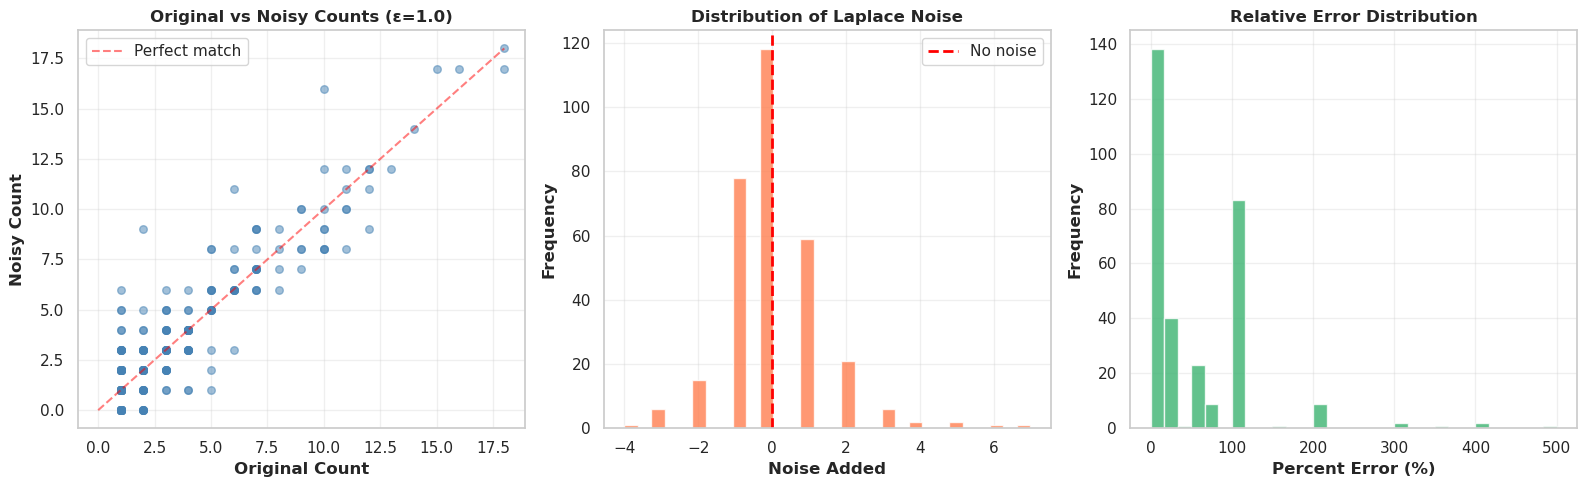

✅ Noise visualization complete!


In [66]:
# ================================
# VISUALIZE NOISE IMPACT
# ================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Original vs Noisy Counts
axes[0].scatter(noisy_groups['count'], noisy_groups['noisy_count'], 
                alpha=0.5, s=30, color='steelblue')
max_count = max(noisy_groups['count'].max(), noisy_groups['noisy_count'].max())
axes[0].plot([0, max_count], [0, max_count], 'r--', alpha=0.5, label='Perfect match')
axes[0].set_xlabel('Original Count', fontweight='bold')
axes[0].set_ylabel('Noisy Count', fontweight='bold')
axes[0].set_title(f'Original vs Noisy Counts (ε={EPSILON})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Noise Distribution
noise_values = noisy_groups['noisy_count'] - noisy_groups['count']
axes[1].hist(noise_values, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No noise')
axes[1].set_xlabel('Noise Added', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Distribution of Laplace Noise', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Percent Error Distribution
axes[2].hist(comparison['percent_error'], bins=30, color='mediumseagreen', 
             edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Percent Error (%)', fontweight='bold')
axes[2].set_ylabel('Frequency', fontweight='bold')
axes[2].set_title('Relative Error Distribution', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Noise visualization complete!')

In [67]:
# ================================
# COMPLETE PRIVACY PIPELINE TEST
# (ACE + Differential Privacy)
# ================================

print('='*80)
print('COMPLETE PRIVACY-PRESERVING PIPELINE')
print('='*80)

# Step 1: Original data
print('\n📊 STEP 1: Original Data')
print(f'   Records: {len(df_sample):,}')
original_stats_full = ace.check_k_anonymity(df_sample, verbose=False)
print(f'   Satisfies {K_ANONYMITY}-anonymity: {original_stats_full["satisfies_k_anonymity"]}')

# Step 2: Apply ACE (k-anonymity)
print(f'\n🛡️  STEP 2: Apply ACE (k={K_ANONYMITY})')
ace_new = ACE(k=K_ANONYMITY, hierarchy=HIERARCHY)
df_k_anonymous = ace_new.enforce_k_anonymity(df_sample, verbose=False)
k_anon_stats = ace_new.check_k_anonymity(df_k_anonymous, verbose=False)
print(f'   Iterations: {len(ace_new.iteration_history)}')
print(f'   Satisfies {K_ANONYMITY}-anonymity: {k_anon_stats["satisfies_k_anonymity"]}')
print(f'   Equivalence classes: {k_anon_stats["num_groups"]}')
print(f'   Generalization levels: {ace_new.current_levels}')

# Step 3: Apply Differential Privacy
print(f'\n🔐 STEP 3: Apply Differential Privacy (ε={EPSILON})')
budget_tracker = PrivacyBudgetTracker(total_epsilon=EPSILON)
budget_tracker.consume(EPSILON, 'Laplace noise on group counts')

df_noisy = add_noise_to_counts(
    df_k_anonymous,
    epsilon=EPSILON,
    qi_attributes=QI_ATTRIBUTES,
    sensitive_attribute=SENSITIVE_ATTRIBUTE
)

print(f'   Noisy groups: {len(df_noisy)}')
print(f'   Privacy budget used: ε={budget_tracker.used_epsilon:.4f}')

# Final Summary
print('\n' + '='*80)
print('✅ PRIVACY PIPELINE COMPLETE!')
print('='*80)
print(f'Original records: {len(df_sample):,}')
print(f'k-anonymity: {K_ANONYMITY} (satisfied: {k_anon_stats["satisfies_k_anonymity"]})')
print(f'Differential privacy: ε={EPSILON}')
print(f'Equivalence classes: {k_anon_stats["num_groups"]}')
print(f'Information loss: Generalized to levels {ace_new.current_levels}')
print('='*80)

COMPLETE PRIVACY-PRESERVING PIPELINE

📊 STEP 1: Original Data
   Records: 1,000
   Satisfies 5-anonymity: False

🛡️  STEP 2: Apply ACE (k=5)
   Iterations: 10
   Satisfies 5-anonymity: False
   Equivalence classes: 210
   Generalization levels: {'Age': 3, 'Sex': 2, 'Education': 3, 'Income': 2, 'BMI': 0, 'GenHlth': 0}

🔐 STEP 3: Apply Differential Privacy (ε=1.0)
✓ Consumed ε=1.0000 for "Laplace noise on group counts"
  Remaining budget: ε=0.0000
   Noisy groups: 310
   Privacy budget used: ε=1.0000

✅ PRIVACY PIPELINE COMPLETE!
Original records: 1,000
k-anonymity: 5 (satisfied: False)
Differential privacy: ε=1.0
Equivalence classes: 210
Information loss: Generalized to levels {'Age': 3, 'Sex': 2, 'Education': 3, 'Income': 2, 'BMI': 0, 'GenHlth': 0}
